### Ziel der Analyse
Diese explorative Datenanalyse (EDA) zielt darauf ab, das Kaufverhalten der Kunden zu verstehen, zentrale Umsatztreiber zu identifizieren und konkrete Optimierungspotenziale für das E-Commerce-Geschäft aufzuzeigen. Darüber hinaus sollen saisonale Trends geprüft werden, um datengetriebene Vorhersagen und Handlungsempfehlungen für zukünftige Marketing- und Vertriebsstrategien ableiten zu können.

In [1]:
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import os
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = "notebook_connected"




module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
price_category_order=['low','medium','high','luxury']
rating_category_order=['poor','average','good','top_rated']
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order=['January','February','March','April','May','June','July','August','September','October','November','December']
valid_order_status=['processing','completed','shipped']
from src.data_loader import load_prepped_data
from src.data_loader import store_bi_data


Die Rohdaten wurden bereits im Vorfeld bereinigt (Data Cleaning) und stehen nun für die explorative Analyse im vorbereiteten Format zur Verfügung.

In [2]:
df_orders=load_prepped_data('orders_prepped.csv')
df_events=load_prepped_data('events_prepped.csv')
df_order_items=load_prepped_data('order_items_prepped.csv')
df_users=load_prepped_data('users_prepped.csv')
df_reviews=load_prepped_data('reviews_prepped.csv')
df_products=load_prepped_data('products_prepped.csv')
valid_orders=df_orders[df_orders['order_status'].isin(valid_order_status)]

### 1. Überblick über den Datensatz

In [3]:
dfs = {
    "Orders": df_orders,
    "Products": df_products,
    "Users": df_users,
    "Order_Items": df_order_items,
    "Events": df_events
}

for name, df in dfs.items():
    print(f"\n{name}")
    print(f"{df.shape[0]} Zeilen und {df.shape[1]} Spalten")
    print(f"Fehlende Werte: {df.isnull().sum().sum()}")
    print("Spalten & Datentypen:")
    print(df.dtypes)


Orders
20000 Zeilen und 7 Spalten
Fehlende Werte: 0
Spalten & Datentypen:
order_id            str
user_id             str
order_date          str
order_status        str
total_amount    float64
order_Month       int64
order_Day           str
dtype: object

Products
2000 Zeilen und 8 Spalten
Fehlende Werte: 0
Spalten & Datentypen:
product_id             str
product_name           str
category               str
brand                  str
price              float64
rating             float64
price_category         str
rating_category        str
dtype: object

Users
10000 Zeilen und 5 Spalten
Fehlende Werte: 0
Spalten & Datentypen:
user_id           str
gender            str
city              str
signup_date       str
signup_month    int64
dtype: object

Order_Items
43525 Zeilen und 7 Spalten
Fehlende Werte: 0
Spalten & Datentypen:
order_item_id        str
order_id             str
product_id           str
user_id              str
quantity           int64
item_price       float64
revenue  

 ### Datenbasis-Struktur
Die Analyse stützt sich auf fünf zentrale Datensätze, die bereits bereinigt und für die explorative Datenanalyse (EDA) vorbereitet wurden.

| Datensatz | Dimensionen | Kerninhalt |
| :--- | :--- | :--- |
| **Orders** | 20.000 Zeilen × 7 Spalten | Transaktionsdaten inklusive Status, Datum und Gesamtwert. |
| **Products** | 2.000 Zeilen × 8 Spalten | Stammdaten der Artikel inklusive Kategorisierung, Marken, Preis und Rating. |
| **Users** | 10.000 Zeilen × 5 Spalten | Demografische Informationen wie Geschlecht, Herkunftsort und Anmeldedaten. |
| **Order_Items** | 43.525 Zeilen × 7 Spalten | Detaillierte Aufschlüsselung der Warenkörbe (Mengen, Einzelpreise, Teilumsätze). |
| **Events** | 80.000 Zeilen × 8 Spalten | Log-Daten zum Nutzerverhalten (Event-Typen, Zeitstempel und zeitliche Einordnung). |

---

####  Datentypen & Schema-Details

<details>
<summary><b>Detaillierte Spaltenübersicht (Klicken zum Ausklappen)</b></summary>

*   **Orders:** `order_id` (str), `user_id` (str), `order_date` (str), `order_status` (str), `total_amount` (float), `order_Month` (int), `order_Day` (str).
*   **Products:** `product_id` (str), `product_name` (str), `category` (str), `brand` (str), `price` (float), `rating` (float), `price_category` (str), `rating_category` (str).
*   **Users:** `user_id` (str), `gender` (str), `city` (str), `signup_date` (str), `signup_month` (int).
*   **Order_Items:** `order_item_id` (str), `order_id` (str), `product_id` (str), `user_id` (str), `quantity` (int), `item_price` (float), `revenue` (float).
*   **Events:** `event_id` (str), `user_id` (str), `product_id` (str), `event_type` (str), `event_timestamp` (str), `hour` (int), `time_of_day` (str), `day` (str).

</details>

---
Diese Struktur erlaubt es, komplexe Zusammenhänge zwischen Nutzerverhalten, Produktattributen und dem tatsächlichen Umsatz über verschiedene Zeiträume hinweg zu analysieren.

### 2. Kundenanalyse

In [4]:
gender_count=df_users['gender'].value_counts()
fig = px.pie(
    names=gender_count.index, 
    values=gender_count.values, 
    title='User Geschlechts Verteilung',
    hole=0.3, 
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(showlegend=True)
fig.show()

Die Analyse der Nutzerdaten zeigt eine sehr ausgeglichene Geschlechterverteilung. Da kein Geschlecht dominant vertreten ist, spricht dies für eine breite Zielgruppenansprache und ein vielseitiges Produktsortiment, das von allen Kundengruppen gut angenommen wird.

**Entwicklung der Neuregistrierungen (pro Monat)**

In [5]:
monthly_signups=df_users.groupby('signup_date')['user_id'].count().reset_index(name='new_registrations')
monthly_signups['signup_date']=pd.to_datetime(monthly_signups['signup_date'])
monthly_signups['signup_month']=monthly_signups['signup_date'].dt.month_name()
monthly_signups.drop('signup_date',axis=1,inplace=True)
monthly_signups=monthly_signups.groupby('signup_month')['new_registrations'].sum()
monthly_signups=monthly_signups.reindex(month_order)
monthly_signups=monthly_signups.reset_index(name='new_registrations')
fig = px.bar(monthly_signups, 
             x='signup_month', 
             y='new_registrations',
             title='Neue Nutzer pro Monat',
             text_auto='.2s', # Formatiert die Zahlen (z.B. 1.2M statt 1200000)
             color='new_registrations',
             color_continuous_scale='Blues')

fig.update_layout(xaxis_title="Monat", yaxis_title="Neue Nutzer", coloraxis_showscale=False)
fig.show()

Die Neukundengewinnung verläuft über die ersten drei Quartale hinweg stabil, verzeichnet jedoch im November und Dezember einen Rückgang. Diese negative Saisonalität zum Jahresende ist äußerst untypisch für das E-Commerce-Geschäft, das normalerweise im vierten Quartal (Q4) durch Events wie Black Friday,Cyber Monday und Weihnachten seinen Höhepunkt erreicht. Dieser Trend deutet stark auf verpasste Marketingpotenziale oder ineffiziente Kampagnen hin.

### 3. Produktanalyse

In [6]:

products_grouped_category=df_products.groupby('category').size()
fig = px.pie(
    names=products_grouped_category.index, 
    values=products_grouped_category.values, 
    title='Produkt Kategorie Verteilung im Shop',
    hole=0.3, 
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(showlegend=True)
fig.show()

Das Sortiment ist breit gefächert, ohne dass eine spezifische Kernkategorie dominiert.  
Es gibt 10 gleichmäßig verteilte Kategorien (z. B. Toys, Beauty, Clothing, Electronics).  
Es sollte in Erwägung gezogen werden, eine Kernkategorien stärker auszubauen, um gezieltere Werbekampagnen für spezifische Zielgruppen zu ermöglichen.Eine stärkere Profilierung in ausgewählten Kategorien könnte dem Shop helfen, sich besser von der Konkurrenz abzuheben.

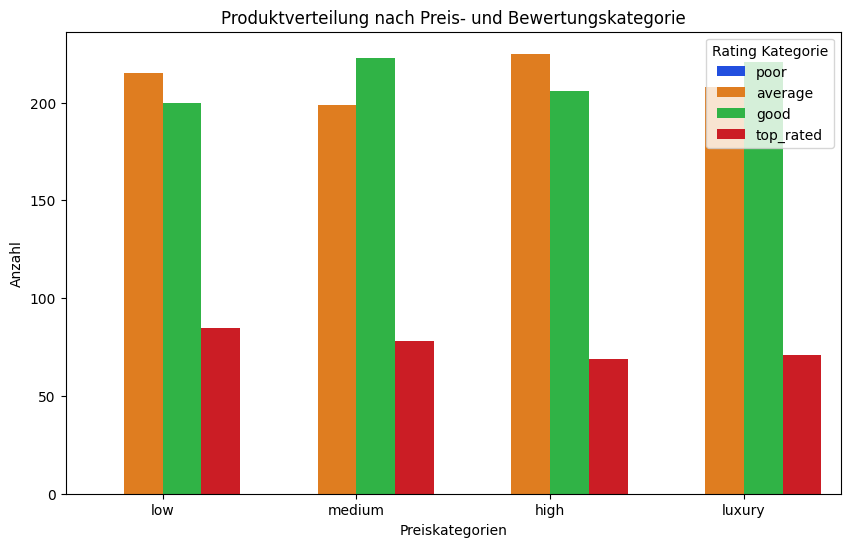

In [7]:
product_perfomance=df_products.groupby(['price_category','rating_category']).size().reset_index(name='count')
plt.figure(figsize=(10,6))
sns.barplot(
    data = product_perfomance,
    x = 'price_category',
    y = 'count',
    hue = 'rating_category',
    order = price_category_order,
    hue_order = rating_category_order,
    palette = 'bright'
)
plt.title('Produktverteilung nach Preis- und Bewertungskategorie')
plt.xlabel('Preiskategorien')
plt.ylabel('Anzahl')
plt.legend(title='Rating Kategorie')

Die Produktbewertungen liegen überwiegend im durchschnittlichen Bereich.
Positiv hervorzuheben ist, dass  keine Bewertungen unter 2.5 (poor) fallen, was auf eine solide Qualität der Produkte hindeutet. Allerdings gibt es zu wenige herrausragende "Top_Rated-Produkte" in den Kategorien high und luxury im vergleich zu low. Diese verteilung spricht für eine hohe Erwartungshaltung der Kunden im höheren Preisbereich, die nicht erfüllt werden kann.

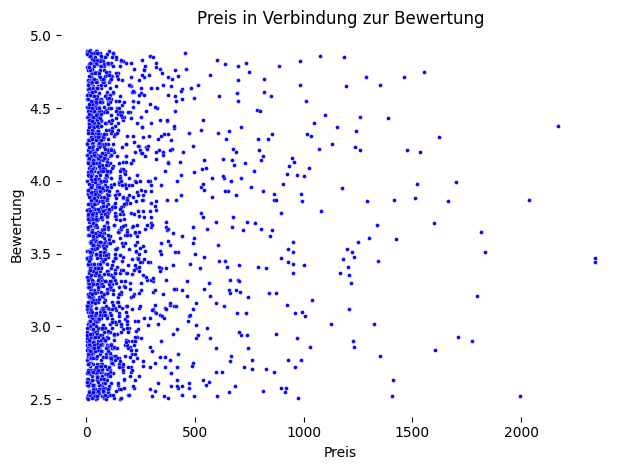

In [8]:
sns.scatterplot(data=df_products,x='price',y='rating',s=8,color='blue')
plt.title('Preis in Verbindung zur Bewertung')
plt.xlabel('Preis')
plt.ylabel('Bewertung')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

Die Streudiagramm-Analyse verdeutlicht, dass die Produktbewertungen im Hochpreissegment signifikant abnehmen, obwohl das Angebot in allen Preiskategorien ähnlich stark vertreten ist. 

**Fazit:** Hochpreisige Produkte verkaufen sich entweder seltener oder erfüllen die gestiegene Erwartungshaltung der Käufer nicht in ausreichendem Maße, um zu einer sehr guten Bewertung zu führen. 

 Um das Vertrauen im oberen Preissegment zu stärken, sollten interne Qualitätskontrollen eingeführt und Käufer gezielt zur Abgabe von Produktbewertungen animiert werden.

In [9]:
product_master=pd.merge(df_order_items,df_products,on=['product_id'],how='left')
product_sales = product_master.groupby(['product_id', 'product_name', 'price','category']).size().reset_index(name='sales_count')
product_sales=product_sales.sort_values('sales_count',ascending=False)
top_products=product_sales.head(10)
fig_prod = px.bar(
    top_products, 
    x='sales_count', 
    y='product_name', 
    title='Top 10 Produkte nach Verkaufszahlen',
    labels={'sales_count': 'Verkaufte Stückzahl', 'product_name': 'Produkt'},
    custom_data=['category'],
    text='product_name'
)
fig_prod.update_traces(
    hovertemplate="<b>%{y}</b><br>Kategorie: %{customdata[0]}<br>Absatz: %{x}<extra></extra>"
)
fig_prod.update_yaxes(showticklabels=False)
fig_prod.update_layout(yaxis={'categoryorder':'total ascending'}, template='plotly_white')
fig_prod.show()

Die Verkaufszahlen der Top 10 Produkte sind relativ homogen; kein einzelnes Produkt hebt sich extrem als Bestseller ab. Dies unterstreicht die vorherige Erkenntnis, dass der Shop von einem breiten, funktionierenden Gesamtsortiment getragen wird, anstatt von wenigen Einzelprodukten abhängig zu sein.

In [10]:
top_categorys=product_sales.groupby(['category'])['sales_count'].sum().reset_index()
top_categorys=top_categorys.sort_values('sales_count',ascending=False)
fig_prod = px.bar(
    top_categorys, 
    x='sales_count', 
    y='category', 
    title='Top Kategorien nach Verkaufszahlen',
    labels={'sales_count': 'Gesamt Verkäufe', 'category': 'Kategorie'},
    text='category'
)
fig_prod.update_yaxes(showticklabels=False)
fig_prod.update_layout(yaxis={'categoryorder':'total ascending'}, template='plotly_white')
fig_prod.show()

**Zusammenfassung der Kategorie-Performance:**
*  Die Kategorie *Groceries* bleibt deutlich hinter den Erwartungen zurück. Hier sollte das Kundenfeedback analysiert und über eine Sortimentsanpassung nachgedacht werden.
*   *Electronics* stellt zwar einen großen Teil des Sortiments dar, wandelt sich aber nicht proportional in hohe Verkaufszahlen um. Die Produktauswahl in diesem Bereich sollte überarbeitet werden.
*   Abgesehen von diesen Auffäligkeiten sind die Verkaufszahlen über die Kategorien hinweg gut ausbalanciert. Der Shop ist dadurch resilienter gegenüber saisonalen Trends (Clothing/Toys).

### 4. Umsatzanalyse

In [11]:
valid_orders['order_date']=pd.to_datetime(valid_orders['order_date'])
valid_orders['order_Month']=valid_orders['order_date'].dt.month_name()
monthly_revenue = valid_orders.groupby('order_Month')['total_amount'].sum().reindex(month_order).reset_index(name='Umsatz in €')

fig = px.bar(monthly_revenue, 
             x='order_Month', 
             y='Umsatz in €',
             title='Gesamtumsatz pro Monat',
             text_auto='.2s', # Formatiert die Zahlen (z.B. 1.2M statt 1200000)
             color='Umsatz in €',
             color_continuous_scale='Greens')

fig.update_layout(xaxis_title="Monat", yaxis_title="Gesamtumsatz (€)", coloraxis_showscale=False)
fig.show()


Der Gesamtumsatz zeigt einen deutlichen Peak im Juli. Erstaunlicherweise bricht der Umsatz im Winter jedoch stark ein, wobei der Dezember den schwächsten Umsatzmonat des Jahres darstellt. Dies bestätigt die zuvor identifizierte negative Winter-Saisonalität.

**Detailanalyse: Wie setzt sich dieser Umsatz zusammen?**

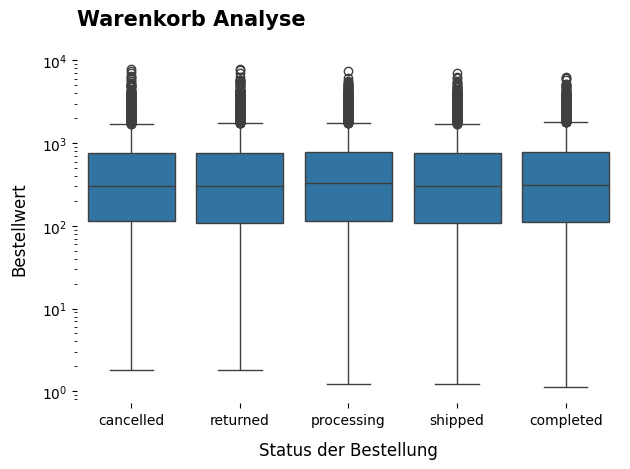

In [12]:
sns.boxplot(data=df_orders,x='order_status',y='total_amount',order=['cancelled','returned','processing','shipped','completed'])
plt.xlabel('Status der Bestellung',fontsize=12, labelpad=10)
plt.ylabel('Bestellwert',fontsize=12, labelpad=10)
plt.title('Warenkorb Analyse',fontsize=15, pad=20, loc='left', fontweight='bold')
sns.despine(left=True, bottom=True)
plt.yscale('log')
plt.tight_layout()
plt.show()

In [13]:
df_orders['total_amount'].describe()

count    20000.000000
mean       595.933447
std        776.063336
min          1.110000
25%        111.355000
50%        308.195000
75%        768.195000
max       7950.740000
Name: total_amount, dtype: float64

Eine initiale Analyse der Warenkörbe (Total Amount) zeigt starke Ausreißer nach oben (bis zu knapp 8.000 €). Solche extremen Werte deuten auf B2B-Kunden oder Großbesteller hin.

Da diese Ausreißer den Durchschnitt stark verzerren, wird in der folgenden Analyse primär der Median-Warenkorb betrachtet, da dieser das Kaufverhalten des typischen B2C-Kunden wesentlich robuster repräsentiert.

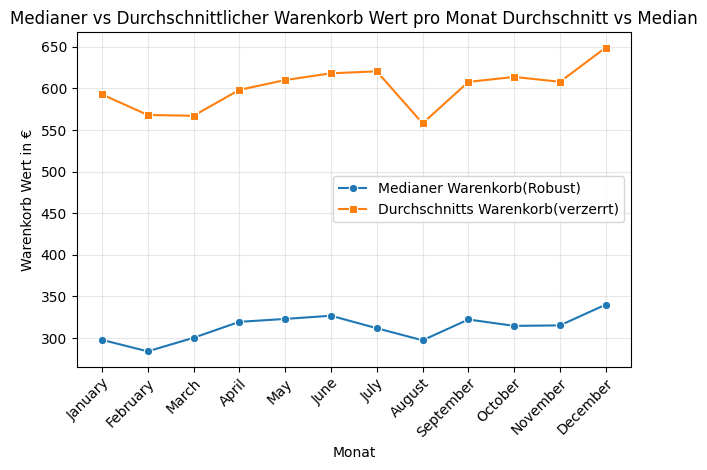

In [14]:
monthly_revenue_median = valid_orders.groupby('order_Month')['total_amount'].median().reindex(month_order).reset_index()
monthly_revenue_mean = valid_orders.groupby('order_Month')['total_amount'].mean().reindex(month_order).reset_index()
sns.lineplot(data=monthly_revenue_median,x='order_Month',y='total_amount',marker='o',label='Medianer Warenkorb(Robust)')
sns.lineplot(data=monthly_revenue_mean,x='order_Month',y='total_amount',marker='s',label='Durchschnitts Warenkorb(verzerrt)')
plt.title('Medianer vs Durchschnittlicher Warenkorb Wert pro Monat Durchschnitt vs Median')
plt.xlabel('Monat')
plt.ylabel('Warenkorb Wert in €')
plt.legend()
plt.xticks(rotation=45,ha='right',rotation_mode='anchor')
#plt.xticks(range(1, 13)) 
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Der mediane sowie der durchschnittliche Warenkorbwert erreichen genau im Dezember ihren Jahreshöchstwert – demselben Monat, in dem der absolute Gesamtumsatz einbricht. 

In [15]:
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(x=monthly_revenue['order_Month'], y=monthly_revenue['Umsatz in €'], name="Gesamtumsatz (€)", opacity=0.7, marker_color='royalblue'),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(x=monthly_revenue_median['order_Month'], y=monthly_revenue_median['total_amount'], name="Median Warenkorb (€)", mode='lines+markers', 
               line=dict(color='firebrick', width=3), marker=dict(size=8)),
    secondary_y=True,
)
fig.update_layout(
    title_text="Jahresverlauf: Gesamtumsatz vs. Median Warenkorbwert",
    template="plotly_white",
    hovermode="x unified",
    coloraxis_showscale=False # Blendet eventuelle Farbskalen aus
)


fig.update_yaxes(title_text="<b>Gesamtumsatz</b> (€)", secondary_y=False)
fig.update_yaxes(title_text="<b>Median Warenkorbwert</b> (€)", secondary_y=True)

fig.show()

Die Kombination aus Gesamtumsatz und Median-Warenkorbwert zeigt das Problem deutlich: Die Warenkörbe werden im Winter zwar größer (höherer Bestellwert pro Kunde), aber der Gesamtumsatz sinkt.

--> Das Umsatzproblem im November und Dezember (Q4) resultiert nicht aus mangelnder Kaufkraft, sondern aus einem **massiven Rückgang der Bestellfrequenz**. Dies korreliert direkt mit den zuvor analysierten schwachen Neukundenzahlen im Winter.

**Ausreißer-Analyse: Welche Kundengruppen verzerren den Warenkorbwert?**

In [16]:
q75=valid_orders['total_amount'].quantile(0.75)
q25=valid_orders['total_amount'].quantile(0.25)
iqr=q75-q25
upper_bound=q75+1.5*iqr
top_orders=valid_orders[valid_orders['total_amount']>=upper_bound]
outlier_users= top_orders.groupby('user_id').agg(
    order_count=('order_id','count'),
    total_spent=('total_amount','sum'),
    avg_spent=('total_amount','mean')
).reset_index()
outlier_users=pd.merge(outlier_users,df_users,on='user_id',how='left')
outlier_users=outlier_users.sort_values('total_spent',ascending=False)
outlier_users=outlier_users.head(10)
fig_user = make_subplots(specs=[[{"secondary_y": True}]])

fig_user.add_trace(
    go.Bar(x=outlier_users['user_id'], y=outlier_users['total_spent'], name="Gesamtausgaben (€)", opacity=0.7, marker_color='royalblue'),
    secondary_y=False,
)

fig_user.add_trace(
    go.Scatter(x=outlier_users['user_id'], y=outlier_users['order_count'], name="Anzahl der Bestellungen", mode='lines+markers', 
               line=dict(color='firebrick', width=3), marker=dict(size=8)),
    secondary_y=True,
)
fig_user.update_layout(
    title_text="Top 10 High Value Kunden(Ausreißer)",
    template="plotly_white",
    hovermode="x unified",
    coloraxis_showscale=False # Blendet eventuelle Farbskalen aus
)


fig_user.update_yaxes(title_text="<b>Gesamtausgaben</b> (€)", secondary_y=False)
fig_user.update_yaxes(title_text="<b>Anzahl Bestellungen</b> (€)", secondary_y=True)

fig_user.show()


Die Segmentierung der Ausreißer bestätigt, dass der durchschnittliche Warenkorbwert massiv von einer kleinen Gruppe von High-Value-Kunden (potenziell B2B) getrieben wird. 

Diese Kunden sollten aus den regulären B2C-Metriken exkludiert und in ein dediziertes B2B/VIP-Programm überführt werden. Kunden wie "U000006" und "U009076" weisen extrem hohe Bestellwerte auf, haben jedoch nur eine einzige Bestellung getätigt. Durch persönliche Account-Manager oder volumenbasierte Rabatte könnte die Bestellfrequenz dieser Key Accounts erhöht werden, um das schwächere B2C-Geschäft im Winter auszugleichen.

In [17]:
top_order_revenue=round(top_orders['total_amount'].sum())
total_revenue=round(valid_orders['total_amount'].sum())
print(f'Der Anteil der B2B Kunden am Gesamt Umsatz beträgt {round((top_order_revenue/total_revenue)*100)}%')


Der Anteil der B2B Kunden am Gesamt Umsatz beträgt 35%


Mit einem Umsatzanteil von **35%** ist die Abhängigkeit des Shops von dieser kleinen Gruppe an Großkunden enorm. Die Etablierung eines professionellen B2B-Kundenbindungsprogramms (CRM) hat höchste Priorität, um diesen Umsatz zu sichern und ganzjährig zu stabilisieren.

### 5. Analyse des Nutzerverhaltens

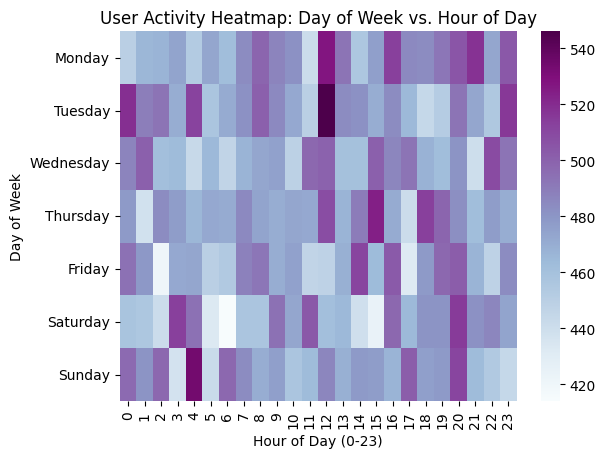

In [18]:
time_activity=df_events.groupby(['day','hour']).size().unstack()
time_activity=time_activity.reindex(days_order)
sns.heatmap(data=time_activity,cmap='BuPu')
plt.title('User Activity Heatmap: Day of Week vs. Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Day of Week')
plt.show()

Die Analyse der Nutzer-Events im Tagesverlauf (Heatmap) liefert wertvolle Erkenntnisse für das Timing von Marketingkampagnen:

*   **Mittagspause (12:00 - 14:00 Uhr):** Eine erste Spitze der Aktivität ist in den Mittagsstunden zu verzeichnen. Dies bietet sich für zeitlich begrenzte "Lunch-Break-Deals" an.
*   **Feierabend (18:00 - 22:00 Uhr):** Die absolute Primetime des Shops liegt am Abend. Hier ist die höchste Dichte an Sessions und potenziellen Conversions zu beobachten.
*   **Wochentage:** Unter der Woche (Montag bis Donnerstag) ist die Abendaktivität am stärksten ausgeprägt. Am Wochenende verschiebt sich die Nutzung leicht in den Nachmittag.

 Marketing Maßnahmen sollten gezielt auf die späten Nachmittags- und Abendstunden (besonders unter der Woche) terminiert werden, um die Conversion-Rate zu maximieren.

In [19]:

valid_orders_grouped=valid_orders.groupby(['order_Day']).size()
valid_orders_grouped=valid_orders_grouped.reindex(days_order)
fig=px.line(data_frame=valid_orders_grouped,
            markers=True,title='Bestellungen pro Wochentag',
            render_mode='svg',
            labels={'order_Day':'Wochentag','value':'Anzahl Bestellungen'}
)
fig.show()

Obwohl der Dienstag und Montag die aktivsten Tage sind, erfolgen die meisten Bestellungen Freitags und Donnerstags. Das Wochenende spielt für das Bestellaufkommen kaum eine Rolle.  
Interessant ist das unter der Woche Dienstag die wenigsten Bestellungen aufgegeben werden. Dies spricht dafür das die Conversion von einem View zu einem Purchase nicht ideal ist.

### Conversion Funnel (Trichteranalyse)

In [20]:
events_grouped=df_events.groupby('event_type').size().reset_index(name='event_count')
events_grouped=events_grouped.sort_values(by='event_count',ascending=False)
fig = px.funnel(events_grouped, x='event_count', y='event_type',title='Conversion Grafik',labels={'event_type':'Event'})
fig.update_traces(
    textinfo="value+percent initial+percent previous"
)

fig.show()

Die Conversion-Rate vom ersten Produktaufruf bis zum Kauf liegt bei 7 %, dies ist ein sehr hoher Wert. Im E-Commerce bereich liegt der Durchschnit bei 3 bis 5 Prozent. Dies könnte auf einen effizienten Kaufprozess oder gut qualifizierten Traffic hindeuten.

Wie ist die Order Conversionrate an den einuzelnen Tagen und Stunden?

Text(50.72222222222221, 0.5, 'Day of Week')

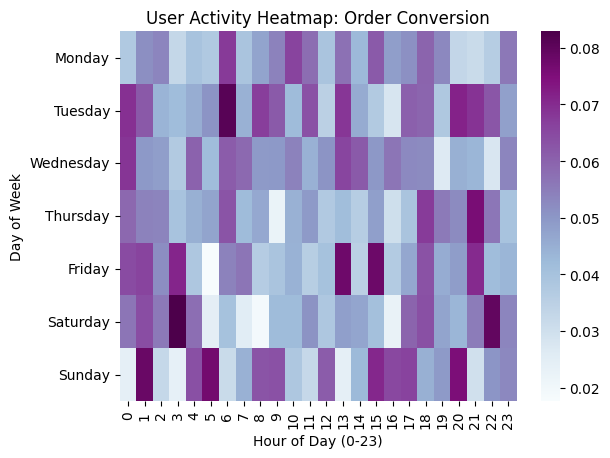

In [21]:
order_conversion_df=pd.merge(valid_orders,df_events,on='user_id',how='left')
order_conversion_df=order_conversion_df.groupby(['day','hour']).agg(
    conversion_count= ('event_type',lambda x:(x == 'purchase').sum()),
    visitor_count= ('user_id','count')
).reset_index()
order_conversion_df['day'] = pd.Categorical(order_conversion_df['day'], categories=days_order, ordered=True)
order_conversion_df = order_conversion_df.sort_values(by=['day', 'hour']).reset_index(drop=True)
order_conversion_df['conversion_rate']=order_conversion_df['conversion_count']/order_conversion_df['visitor_count']
order_conversion_df['hour']= order_conversion_df['hour'].astype(int)
order_conversion_data= order_conversion_df.pivot(index='day',columns='hour',values='conversion_rate')
sns.heatmap(data=order_conversion_data,cmap='BuPu')
plt.title('User Activity Heatmap: Order Conversion')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Day of Week')

Die Analyse der Konversionsrate liefert präzisere Erkenntnisse als die reine Aktivitätsbetrachtung:

* **Maximale Effizienz**: Die höchste Konversionsrate liegt im dunkelroten Bereich bei ca. **8 %**.
* **Peak-Verschiebung**: Während die meisten Nutzer dienstags um 12 Uhr im Shop sind, konvertieren sie **am Freitag Mittag und am Wochenende** am effektivsten
* **Abend-Schwäche**: Die Konversion sinkt donnerstags und freitags ab 18 Uhr merklich ab, was die Abendstunden für teure Werbeplatzierungen weniger attraktiv macht.

 Marketing-Aktionen sollten nicht auf die Zeit des höchsten Traffics, sondern auf die Zeit der höchsten Konversion (z. B. Dienstag 6 Uhr) getimt werden, um die ROI-Effizienz zu maximieren

Jetzt könnte man sich anschauen wie lange ein User zu seiner ersten Bestellung braucht

In [22]:
user_to_order= pd.merge(valid_orders,df_users,on=['user_id'])
user_to_order['order_date']=pd.to_datetime(user_to_order['order_date'])
user_to_order['signup_date']=pd.to_datetime(user_to_order['signup_date'])
user_to_order['days_to_order']=(user_to_order['order_date']-user_to_order['signup_date']).dt.days
days_to_order_invalid=user_to_order[user_to_order['days_to_order']<0]
print(f"Der Datensatz hat {user_to_order.shape[0]} Einträge und {days_to_order_invalid.shape[0]} negative days_to_order Einträge.")



Der Datensatz hat 12014 Einträge und 5958 negative days_to_order Einträge.


Daraus lässt sich ableiten das ca. 50% der Kunden eine Gastbestellung durchführen. Dieser Wert ist deutlich zu hoch. Man sollte die Registrierung attraktiver machen um mehr Werbe-Kanäle zu haben.

In [23]:
def get_buyer_type(r):
        if r <0: return 'Gast_Bestellung'
        if r == 0: return 'Sofort-Kauf'
        if r >0: return 'Überlegender Käufer'
        return 'poor'
user_to_order['buyer_type']=user_to_order['days_to_order'].apply(get_buyer_type)
user_type_count=user_to_order.groupby('buyer_type').size().reset_index(name='count')
fig = px.bar(user_type_count, 
             x='buyer_type', 
             y='count', 
             color='buyer_type',
             text='count',  # Zeigt die exakte Zahl an
             title='Detaillierte Analyse der Käufer-Typen',
             template='plotly_white')


fig.update_traces(texttemplate='%{text}', textposition='outside')
fig.update_layout(showlegend=False, yaxis_title="Anzahl User", xaxis_title="Käufer-Typ")

fig.show()

 Der Anteil von Gastbestellungen wird noch mal deutlich,dieser Wert ist deutlich zu hoch. Man sollte die Registrierung attraktiver machen um mehr Werbe-Kanäle zu haben.
 Dies würde auch die Kundenbindung verstärken und ist essenziell für e-commerce um langfristig zu überleben.

Korrelation zwischen Preis und Absatzmenge: -0.06


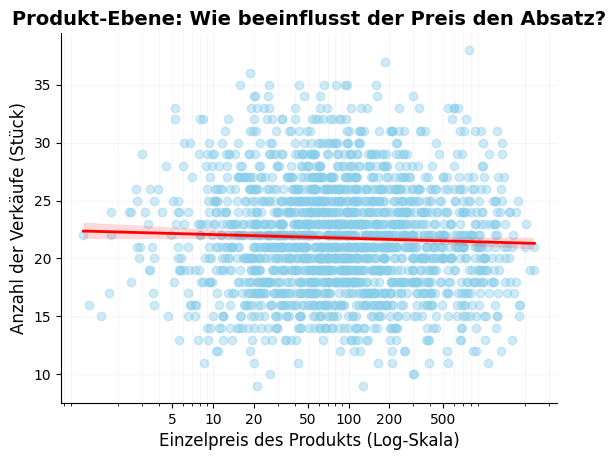

In [24]:
#Korrelation Preis zu Order count
sns.regplot(
    data=product_sales, 
    x='price', 
    y='sales_count', 
    scatter_kws={'alpha':0.4, 'color':'skyblue'}, 
    line_kws={'color':'red', 'lw':2},
    logx=True
)
plt.xscale('log') 
plt.title('Produkt-Ebene: Wie beeinflusst der Preis den Absatz?', fontsize=14, fontweight='bold')
plt.xlabel('Einzelpreis des Produkts (Log-Skala)', fontsize=12)
plt.ylabel('Anzahl der Verkäufe (Stück)', fontsize=12)
plt.xticks([5, 10, 20, 50, 100, 200, 500], ['5', '10', '20', '50', '100', '200', '500'])
sns.despine()
plt.grid(True, which="both", ls="-", alpha=0.1)
corr = product_sales['price'].corr(product_sales['sales_count'])
print(f"Korrelation zwischen Preis und Absatzmenge: {corr:.2f}")

plt.show()


Es gibt nahezu keine Korrelation zwischen Bestellungen und dem einzelpreis der Produkte,
dies zeigt eine geringe Preis-Elastizität beim User.
Da die Kunden kaum preissensibel reagieren, besteht hier ein erheblicher Spielraum für Margenoptimierungen. Der Shop sollte davon absehen, über aggressive Rabattaktionen zu konkurrieren, und stattdessen den Fokus auf Wertigkeit, Qualität und Service legen, um so mehr Vertrauen und eine höhere Kundenbindung aufzubauen.

Wie ist die Wiederkaufsrate?

In [25]:
user_orders = valid_orders.groupby('user_id').size()
repeat_customers = (user_orders > 1).sum()
total_customers = df_users['user_id'].nunique()
retention_rate = (repeat_customers / total_customers) * 100
print(f"Wiederkaufsrate: {retention_rate:.2f}%")

Wiederkaufsrate: 33.63%


Eine Wiederkaufsrate von 33,63% ist sehr gut. Für so einen breit aufgestellten Online-Shop. Sie zeigt solide Kundenbindung, jedoch sind weitere Analysen nötig um diese Zahl richtig zu interpretieren.

**Wie ist die Retentionrate in den einzelnen User Gruppen(Cohort Analysis)**

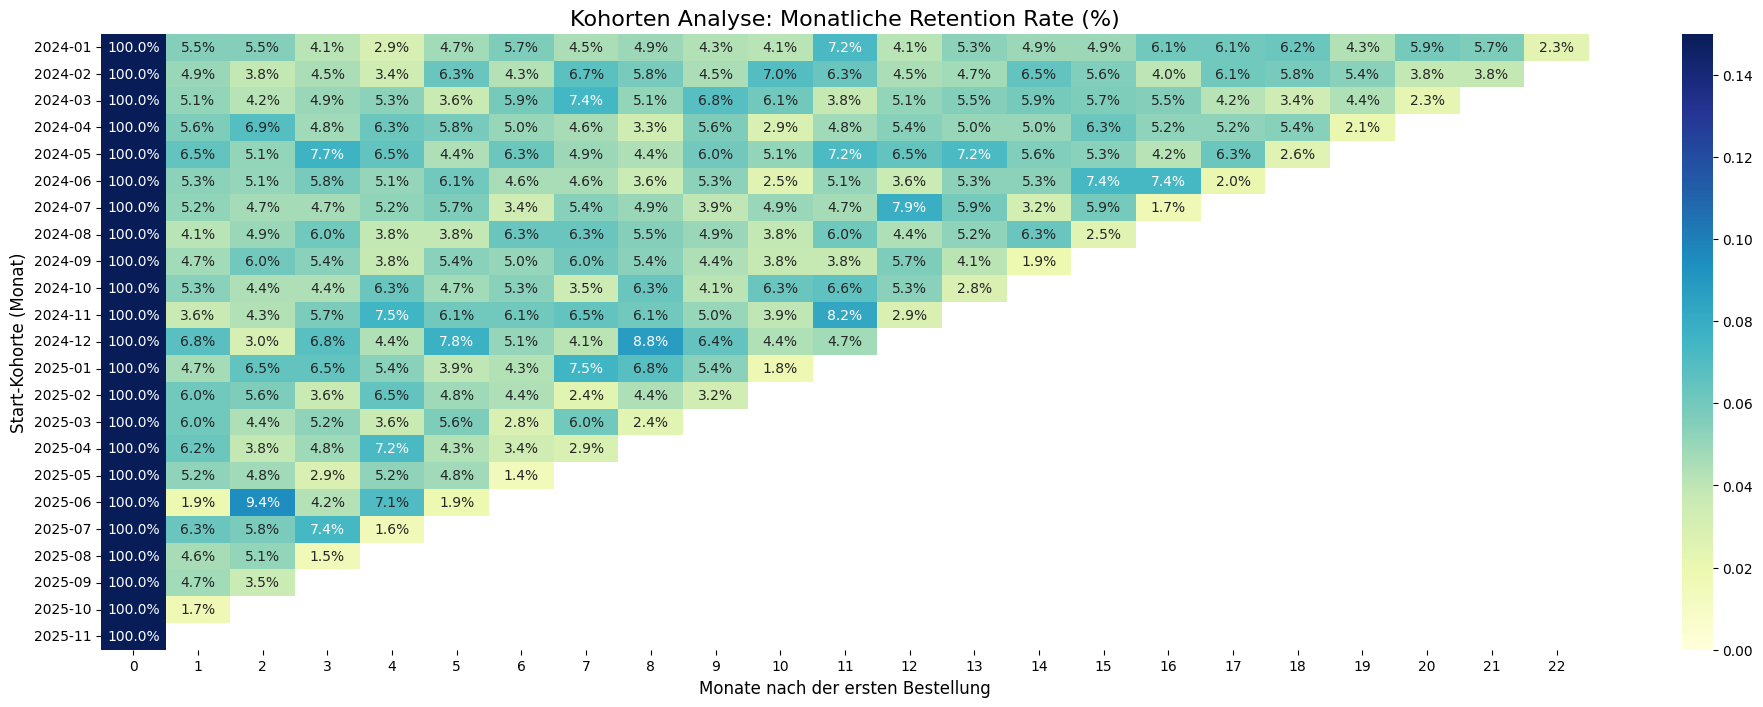

In [26]:
valid_orders['cohort'] = valid_orders.groupby('user_id')['order_date'].transform('min').dt.to_period('M')
valid_orders['order_period'] = valid_orders['order_date'].dt.to_period('M')
valid_orders['cohort_index']=(valid_orders['order_period']-valid_orders['cohort']).apply(lambda x: x.n)
cohort_counts=valid_orders.groupby(['cohort','cohort_index'])['user_id'].nunique().reset_index()
cohort_pivot=cohort_counts.pivot(index='cohort',columns='cohort_index',values='user_id')
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)
plt.figure(figsize=(24, 8))
sns.heatmap(retention_matrix, annot=True, fmt='.1%', cmap='YlGnBu', vmin=0, vmax=0.15)
plt.title('Kohorten Analyse: Monatliche Retention Rate (%)', fontsize=16)
plt.xlabel('Monate nach der ersten Bestellung', fontsize=12)
plt.ylabel('Start-Kohorte (Monat)', fontsize=12)
plt.show()

Analyse Kundenbindungs Matrix:
Auch wenn im selben Monat nur wenige Leute mehrfach bestellen, zeigt die Langzeitübersicht ein gutes Bild. Ungefähr 6 % der Kunden kommen über fast zwei Jahre hinweg immer wieder zurück. Das ist unsere Basis an Stammkunden.
Besonders bei den Kunden, die Anfang 2024 (Januar bis September) zum ersten Mal da waren, sieht man eine sehr flache Kurve. Die Rate bleibt konstant bei 6 %. Das spricht dafür, dass die Leute mit dem Shop zufrieden sind und nicht nach ein paar Monaten komplett abspringen.
Auffälligkeit im Juni 2025: Hier gibt es einen Knick. Nach dem ersten Monat bricht die Rate auf 1,9 % ein, geht dann aber im zweiten Monat sofort wieder auf 9,4 % hoch. Das sieht stark nach einem Problem von außen aus – vielleicht waren wichtige Produkte nicht lieferbar oder es gab Probleme beim Versand, die erst einen Monat später gelöst wurden.
Fazit: Dass die Raten über 22 Monate so stabil bleiben, zeigt, dass es eine gewisse Stammkundschaft gibt. Jedoch ist die rate insgesamt für den e-commerce bereich zu niedrig. Eine durchschnittliche Rate nach 24 Monaten liegt bei 15 bis 25%. Daraus lässt sich schließen das im Geschäftsmodell an der Neukundenbindung gearbeitet werden muss, dies sieht man auch an der Retention in Kohorte 2025-10 die auf 1.7% absinkt.

### 6. Fazit und Handlungsempfehlungen

Die vorliegende explorative Datenanalyse (EDA) liefert ein detailliertes Bild des aktuellen E-Commerce-Geschäfts und deckt wertvolle strategische Hebel auf. Basierend auf den validierten Mustern ergeben sich folgende zentrale Handlungsfelder:

1. **Strukturelles B2B-Potenzial:** 
   Eine kleine Gruppe von Ausreißer-Transaktionen (High-Value-Kunden) generiert massive 35% des Gesamtumsatzes. Diese Kundengruppe weist jedoch eine fatale Schwäche auf: Accounts wie "U000006" und "U009076" haben trotz extrem hoher Bestellwerte nur eine einzige Bestellung getätigt.  
   * **Handlungsempfehlung:** Diese Kunden müssen aus den B2C-Metriken exkludiert werden. Die Einführung eines exklusiven B2B-Partnerprogramms (mit Account-Management und volumenbasierten Rabatten) hat höchste Priorität, um die Bestellfrequenz dieser Key Accounts zu erhöhen und den Umsatz ganzjährig zu sichern.

2. **Die Winter-Lücke und schwache Bestellfrequenz:** 
   Entgegen dem E-Commerce-Branchentrend (Q4/Black Friday) bricht der absolute Gesamtumsatz im Winter ein, wobei der Dezember der schwächste Monat ist. Gleichzeitig erreichen der mediane und durchschnittliche Warenkorbwert im Dezember ihren Jahreshöchstwert.  
   * **Handlungsempfehlung:** Das Umsatzproblem ist nicht auf mangelnde Kaufkraft zurückzuführen, sondern auf einen massiven Rückgang der Bestellfrequenz und sinkende Neuregistrierungen. Marketingbudgets müssen im Q4 gezielt zur Reaktivierung bestehender Kunden eingesetzt werden, um diesen Einbruch abzufangen.

3. **Nutzen durch Werbung maximieren durch Conversion-basiertes Timing:** 
   Mit 7% (View-to-Purchase) hat der Shop eine exzellente Conversion-Rate, was für einen effizienten Kaufprozess oder gut qualifizierten Traffic spricht. Allerdings zeigt die Order-Conversion-Heatmap eine massive Peak-Verschiebung: Während die höchste Traffic-Aktivität dienstags um 12 Uhr sowie generell an Wochentagen abends (18-22 Uhr) stattfindet, konvertieren Nutzer am Freitagmittag, am Wochenende und in den frühen Morgenstunden (z. B. Dienstag 6 Uhr) am effektivsten (bis zu 8%). Donnerstags und freitags ab 18 Uhr sinkt die Conversion merklich.  
   * **Handlungsempfehlung:** Marketingbudgets und teure Werbeplatzierungen sollten nicht auf die Zeiten des höchsten Traffics, sondern exakt auf die echten Conversion-Peaks getimt werden, um den Nutzen durch Werbung zu maximieren.

4. **Kundenbindung  & Registrierungs-Defizit:** 
   Rund 50% der Käufer führen Gastbestellungen durch, was für einen E-Commerce-Shop deutlich zu hoch ist. Zwar liegt die generelle Wiederkaufsrate bei soliden 33,63%, jedoch zeigt die Kohortenanalyse, dass die Langzeit-Retention nach 24 Monaten bei nur ca. 6% stagniert (üblich sind 15-25%), bei neueren Kohorten (z. B. 2025-10) fällt sie sogar auf 1,7%.  
   * **Handlungsempfehlung:** Die Registrierung muss durch Boni deutlich attraktiver gestaltet werden, um Marketing-Kanäle aufzubauen. Das Geschäftsmodell erfordert dringend Maßnahmen zur Neukundenbindung, um Einmalkäufer in loyale Stammkunden zu verwandeln.

5. **Preiselastizität & Margenpotenzial:** 
   Die Korrelation zwischen Produktpreis und Absatzmenge liegt bei nahezu null (-0.06), was eine extrem geringe Preiselastizität beweist.  
   * **Handlungsempfehlung:** Da die Kunden kaum preissensibel reagieren, bietet sich hier ein erheblicher Spielraum für Margenoptimierungen. Der Shop sollte auf aggressive Rabattaktionen verzichten und stattdessen durch Wertigkeit, Qualität und Service überzeugen, um Kundenbindung aufzubauen.

6. **Qualitätsmanagement & Sortimentsprofilierung:** 
   Die ausgeglichene Geschlechterverteilung und homogenen Bestseller-Zahlen zeigen ein gut balanciertes Sortiment. Dennoch verzeichnen die Preisklassen "high" und "luxury" proportional zu wenige "Top_Rated"-Bewertungen, was auf nicht erfüllte Erwartungshaltungen hindeutet. Zudem schwächelt die Kategorie *Groceries* stark, während *Electronics* bei großem Angebot kaum konvertiert.  
   * **Handlungsempfehlung:** Strenge Qualitätskontrollen im Hochpreissegment einführen und Reviews gezielt auswerten. Die Produktauswahl in *Electronics* überarbeiten und das Feedback zu *Groceries* evaluieren. Eine Kernkategorie sollte etabliert werden, um sich besser von der Konkurrenz abzuheben und ein besseres image aufzubauen.

**Ausblick & Forecasting:**  
Auf Basis der identifizierten Trends – wie der starken Sommer-Saisonalität, dem Wochentag-Wochenend-Muster und der geringen Preiselastizität – ist eine prädiktive Umsatzprognose (Forecasting) grundsätzlich möglich,aber aufgrund struktureller Veränderungen nur eingeschränkt aussagekräftig

### 7. Datenexport & Vorbereitung für Streamlit

Im Anschluss an diese EDA wird ein interaktives Streamlit Dashboard entwickelt. Um dort ein sauberes und performantes Datenmodell aufbauen zu können, werden die bereinigten Kerndatensätze sowie die in Python berechneten Hilfstabellen (z. B. für komplexe Metriken) in diesem finalen Schritt separat exportiert.

In [27]:

valid_orders['customer_segment'] = valid_orders['total_amount'].apply(
    lambda x: 'B2B (High Value)' if x >= upper_bound else 'B2C (Regular)'
)

valid_orders = pd.merge(valid_orders, user_to_order[['order_id', 'buyer_type']], on='order_id', how='left')


store_bi_data(valid_orders,'pbi_orders.csv')
store_bi_data(df_users,'pbi_users.csv')
store_bi_data(df_products,'pbi_products.csv')
store_bi_data(df_events,'pbi_events.csv')
store_bi_data(df_order_items,'pbi_order_items.csv')
store_bi_data(order_conversion_df,'pbi_order_conversion.csv')
store_bi_data(retention_matrix,'pbi_retention_matrix.csv')